In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from kret_studies import *
from kret_studies.notebook import *
from kret_studies.complex import *

logger = get_notebook_logger()

Loaded environment variables from /Users/Akseldkw/coding/Columbia/RL-Project/.env.


INFO:datasets:JAX version 0.7.2 available.


In [4]:
from waymo_agent import *

In [5]:
G = ox.load_graphml(filepath=MAP_DIR / MANHATTAN_RAW_GRAPH)

In [6]:
# fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.5)

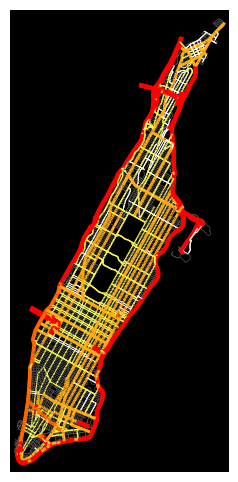

In [7]:
from waymo_agent.osmnx.osmnx_constants import OSMNXConstants


edge_colors, edge_widths = OSMNXConstants.get_edge_colors(G)

# 4. Plot with both attributes
fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_color=edge_colors,
    edge_linewidth=edge_widths,
    bgcolor="black",
    figsize=(6, 6),  # Bigger size helps see the width differences
    show=True,
)

In [8]:
len(G.nodes), len(G.edges)

(4619, 9901)

## Sparsify the graph

In [17]:
G = ox.load_graphml(filepath=MAP_DIR / MANHATTAN_PROCESSED_GRAPH)

In [18]:
G_sparse = sparsify_graph(G)

Removing 4681 non-major edges...
Graph after edge removal: G_sparsified.number_of_nodes()=3522, G_sparsified.number_of_edges()=5219
Cleaning all edge attributes before simplification...
Merged attributes: {'osmid', 'name', 'tunnel', 'ref', 'bridge', 'lanes', 'reversed'}
Simplifying topology...
Final simplified graph: G_simplified.number_of_nodes()=1196, G_simplified.number_of_edges()=2382


In [19]:
edge_colors, edge_widths = OSMNXConstants.get_edge_colors(G_sparse)

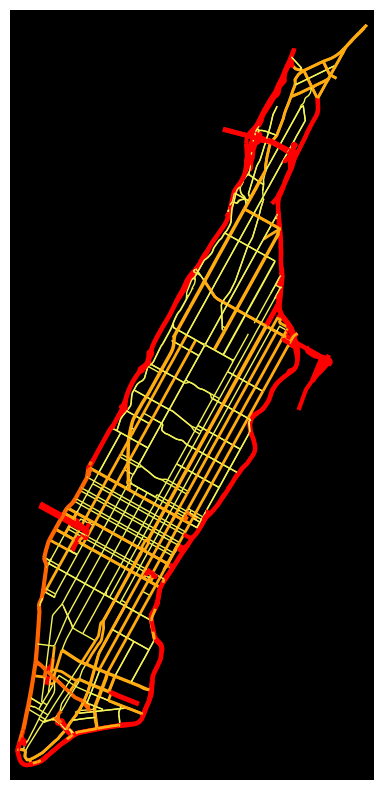

In [20]:
fig, ax = ox.plot_graph(
    G_sparse,
    node_size=0,
    edge_color=edge_colors,
    edge_linewidth=edge_widths,  # <--- Pass the new list here
    bgcolor="black",
    figsize=(10, 10),  # Bigger size helps see the width differences
    show=True,
)
fig.savefig(IMG_DIR / MANHATTAN_SPARSE_COLORFUL, dpi=1_000, bbox_inches="tight", facecolor=fig.get_facecolor())

In [21]:
from waymo_agent import *

In [22]:
from waymo_agent.osmnx.inspect import *
from waymo_agent.osmnx.osmnx_constants import *
from waymo_agent.osmnx.sparsify import *
from waymo_agent.osmnx.utils import _collect_unique_graph_attr, _max_speed_int

In [23]:
MAJOR_ROAD_TYPES_SET

{'motorway',
 'motorway_link',
 'primary',
 'primary_link',
 'secondary',
 'secondary_link',
 'trunk',
 'trunk_link'}

In [24]:
tunnel_set = _collect_unique_graph_attr(G, "lanes")
tunnel_set

{'1', '2', '3', '4', '5', '6'}